In [1]:
import pandas as pd
import numpy as np

In [2]:
np.random.seed(42)

n = 2000

education = ['Bachelor', 'Master', 'PhD']
roles = ['Developer', 'Data Analyst', 'Manager',
         'Designer', 'Data Scientist']
company = ['Startup', 'MNC', 'Medium Scale']

data = pd.DataFrame({
    'EmployeeID': range(1, n+1),
    'Age': np.random.randint(22, 60, n),
    'Gender': np.random.choice(['Male', 'Female'], n),
    'EducationLevel': np.random.choice(education, n),
    'YearsOfExperience': np.random.randint(0, 30, n),
    'JobRole': np.random.choice(roles, n),
    'SkillsScore': np.random.randint(1, 11, n),
    'Certifications': np.random.randint(0, 8, n),
    'CompanyType': np.random.choice(company, n),
    'WorkHoursPerWeek': np.random.randint(35, 60, n)
})

In [3]:
salary = (
    30000 +
    data['YearsOfExperience'] * 4000 +
    data['SkillsScore'] * 2500 +
    data['Certifications'] * 1500
)

salary += data['EducationLevel'].map({
    'Bachelor': 5000,
    'Master': 15000,
    'PhD': 30000
})

salary += data['JobRole'].map({
    'Developer': 10000,
    'Data Analyst': 12000,
    'Manager': 25000,
    'Designer': 8000,
    'Data Scientist': 20000
})

salary += np.random.normal(0, 5000, n)

data['Salary'] = salary.astype(int)

data.to_csv("employee_salary.csv", index=False)

print(data.head())

   EmployeeID  Age  Gender EducationLevel  YearsOfExperience         JobRole  \
0           1   50    Male       Bachelor                 10    Data Analyst   
1           2   36  Female         Master                 29         Manager   
2           3   29    Male         Master                 21    Data Analyst   
3           4   42  Female         Master                 28  Data Scientist   
4           5   40    Male       Bachelor                  3  Data Scientist   

   SkillsScore  Certifications   CompanyType  WorkHoursPerWeek  Salary  
0           10               6  Medium Scale                58  107796  
1            7               1  Medium Scale                38  200834  
2            6               6       Startup                54  158565  
3           10               3       Startup                52  208739  
4            5               3           MNC                59   85689  


In [4]:
import pandas as pd

df = pd.read_csv("employee_salary.csv")

#missingvalues
df.fillna(df.mode().iloc[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print(df.isnull().sum())

EmployeeID           0
Age                  0
Gender               0
EducationLevel       0
YearsOfExperience    0
JobRole              0
SkillsScore          0
Certifications       0
CompanyType          0
WorkHoursPerWeek     0
Salary               0
dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical = [
    'Gender',
    'EducationLevel',
    'JobRole',
    'CompanyType'
]

for col in categorical:
    df[col] = le.fit_transform(df[col])

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical = [
    'Age',
    'YearsOfExperience',
    'SkillsScore',
    'Certifications',
    'WorkHoursPerWeek'
]

df[numerical] = scaler.fit_transform(df[numerical])

In [7]:
print(df['Salary'].describe())

count      2000.000000
mean     139884.836500
std       37505.849112
min       42875.000000
25%      111077.250000
50%      140494.000000
75%      168959.750000
max      226304.000000
Name: Salary, dtype: float64


In [8]:
len(df)

2000

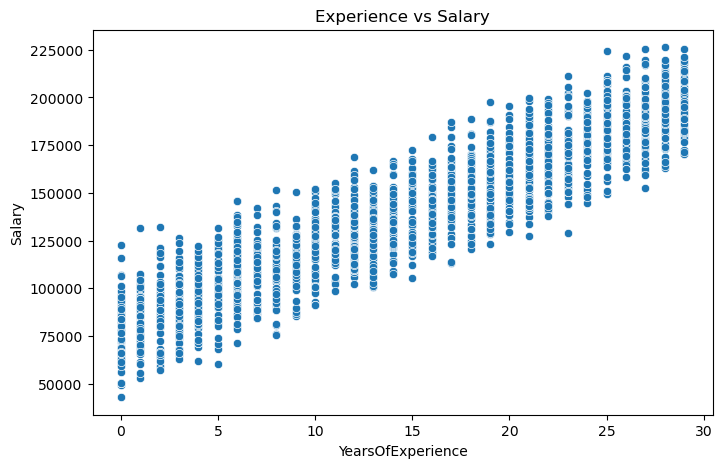

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='YearsOfExperience',
    y='Salary',
    data=data
)

plt.title("Experience vs Salary")
plt.show()

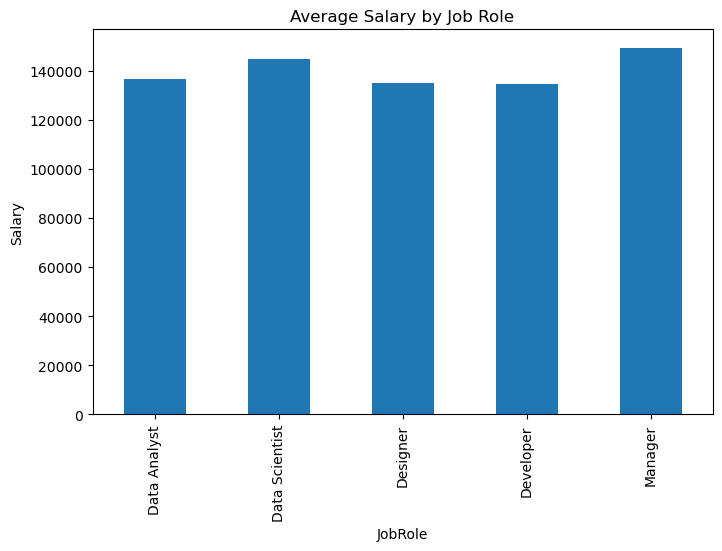

In [10]:
plt.figure(figsize=(8,5))

data.groupby('JobRole')['Salary'].mean().plot(
    kind='bar'
)
plt.title("Average Salary by Job Role")
plt.ylabel("Salary")
plt.show()

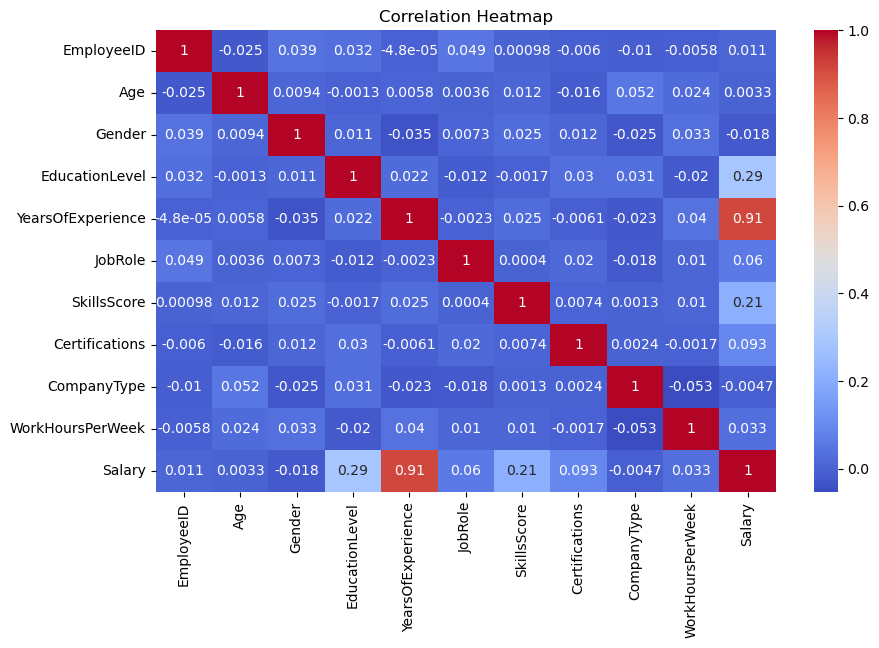

In [11]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

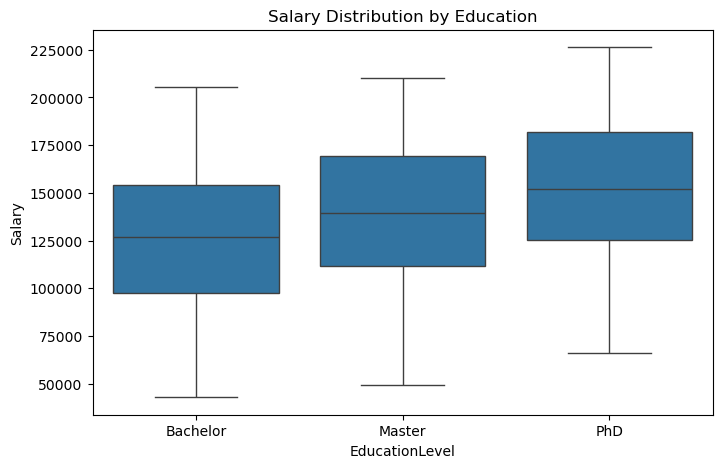

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='EducationLevel',
    y='Salary',
    data=data
)

plt.title("Salary Distribution by Education")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(
    ['Salary', 'EmployeeID'],
    axis=1
)

y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = mean_squared_error(y_test, predictions) ** 0.5
    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R² Score"]
)

comparison_df.sort_values(by="R² Score", ascending=False)

,Model,MAE,RMSE,R² Score
2,Random Forest,5975.260425,7279.240152,0.959410
0,Linear Regression,6346.873014,7571.025476,0.956091
1,Decision Tree,9005.450000,11536.127612,0.898054


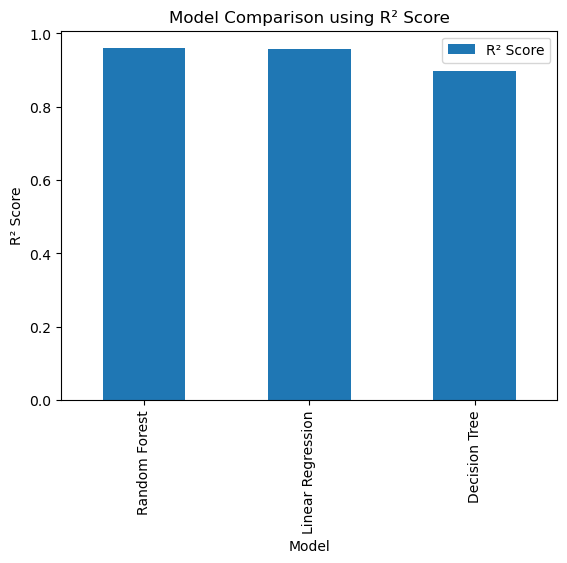

In [19]:
import matplotlib.pyplot as plt

comparison_df.sort_values(by="R² Score", ascending=False).plot(
    x="Model",
    y="R² Score",
    kind="bar"
)

plt.title("Model Comparison using R² Score")
plt.ylabel("R² Score")
plt.show()

In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, pred)

rmse = mean_squared_error(
    y_test,
    pred
) ** 0.5

r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 5975.2604249999995
RMSE: 7279.240151690061
R2 Score: 0.9594098968075635


In [17]:
import pickle

pickle.dump(
    rf,
    open("salary_model.pkl", "wb")
)